Diffusion (heat) equation:
$$u_t = u_{xx}, \quad 0 \le x \le 1,\quad t \ge 0$$
Initial condition
$$u(x,0)= \sin\left(\frac{\pi x}{2}\right) + \frac{1}{2}\sin(2\pi x)$$
Boundary conditions
$$u(0,t)=0,\quad
u(1,t)=e^{-\pi^2 t/4}$$
We solve using Forward Euler with $$\mu = \frac{\Delta t}{\Delta x^2} = 0.5,\quad 0.509$$

Let grid: $$x_j = j \Delta x,\quad j=0,\dots,N$$ and $$t_n = n \Delta t,\quad n=0,\dots,M $$
      
    
Forward Euler:     $$u_j^{n+1} = u_j^n + \mu (u_{j+1}^n - 2u_j^n + u_{j-1}^n)$$
Boundary enforced each step: $$u_0^n = 0,\quad
u_N^n = e^{-\pi^2 t_n/4}$$
Forward Euler requires: $$\mu \le \frac12$$
so: $\mu=\frac12$ is borderline stable
  and $\mu=0.509$ is unstable

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
N = 50                  # spatial grid points
dx = 1/N
T = 0.2                 # final time
dt_mu05   = 0.5*dx**2
dt_mu0509 = 0.509*dx**2

def run(mu):

    dt = mu*dx**2
    M = int(T/dt)

    x = np.linspace(0,1,N+1)
    t = np.linspace(0,T,M+1)

    # initial condition
    u = np.sin(np.pi*x/2) + 0.5*np.sin(2*np.pi*x)

    sol = [u.copy()]

    for n in range(M):
        u_new = u.copy()

        # interior
        for j in range(1,N):
            u_new[j] = u[j] + mu*(u[j+1] - 2*u[j] + u[j-1])

        # boundary
        u_new[0] = 0
        u_new[-1] = np.exp(-np.pi**2*t[n+1]/4)

        u = u_new
        sol.append(u.copy())

    return np.array(sol), x, t

sol_mu05, x, t = run(0.5)
sol_mu0509, _, _ = run(0.509)

print("Done.")


Done.


**No external solvers for code **

Max error μ=0.5 = 2.181057951855525e-05
Max error μ=0.509 = 4337.222308346193


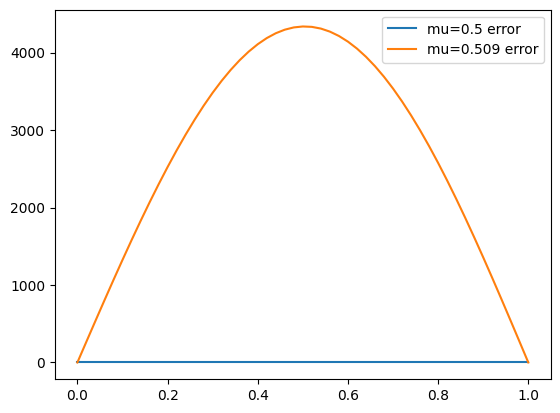

In [2]:
def exact(x,t):
    return np.exp(-np.pi**2*t/4)*np.sin(np.pi*x/2) + \
           0.5*np.exp(-4*np.pi**2*t)*np.sin(2*np.pi*x)

u_exact = exact(x,T)

err1 = np.abs(sol_mu05[-1] - u_exact)
err2 = np.abs(sol_mu0509[-1] - u_exact)

print("Max error μ=0.5 =", np.max(err1))
print("Max error μ=0.509 =", np.max(err2))

plt.plot(x, err1, label='mu=0.5 error')
plt.plot(x, err2, label='mu=0.509 error')
plt.legend()
plt.show()
